# Modeling and Validation

## Objective

The goal of this notebook is to build and evaluate regression models in a structured, explainable, and reproducible way.

This notebook focuses on:

- building baseline regression models
- creating a reliable validation framework
- comparing model performance fairly
- investigating preprocessing effects
- evaluating model stability
- documenting modeling decisions clearly

The focus is not on advanced Kaggle optimization.

Instead, the goal is to understand:

- how different models behave
- which preprocessing decisions help
- whether models generalize reliably
- how to evaluate models scientifically

---

# Why Validation Matters

A machine learning model should not only perform well on training data.

The real goal is to perform well on unseen data.

To estimate generalization performance, we use cross-validation.

Cross-validation allows us to:

- test models across multiple validation splits
- estimate performance stability
- reduce dependence on a single train/test split
- compare models more fairly

---

# Modeling Strategy

We will begin with simple and interpretable models before testing more complex approaches.

The workflow will follow these stages:

1. Prepare the modeling dataset
2. Define validation and scoring methods
3. Build a simple baseline model
4. Train linear regression models
5. Compare raw vs log-transformed target modeling
6. Evaluate model stability across folds
7. Compare performance and interpret findings

---

# Expected Outcome

By the end of this notebook, we should have:

- a reusable validation framework
- reproducible evaluation procedures
- baseline regression benchmarks
- comparison between simple models
- understanding of target transformation effects
- a clear modeling direction for future experiments

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

# 1. Load and Prepare Modeling Data

We first load the dataset and separate the target variable from the feature columns.

For modeling:

- `X` contains the input features
- `y` contains the target we want to predict
- `ID` is removed because it is only an identifier

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

y = train["target"]
X = train.drop(columns=["ID", "target"])
X_test = test.drop(columns=["ID"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (4459, 4991)
y shape: (4459,)
X_test shape: (49342, 4991)


## Remove Constant Features

From the preparation EDA, we found that some columns are constant.

Constant features contain no variation and cannot help a model learn.

We remove them here before modeling.

In [3]:
feature_variances = X.var()
constant_cols = feature_variances[feature_variances == 0].index

X = X.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

print("Removed constant features:", len(constant_cols))
print("X shape after removal:", X.shape)
print("X_test shape after removal:", X_test.shape)

Removed constant features: 256
X shape after removal: (4459, 4735)
X_test shape after removal: (49342, 4735)


# 2. Validation Framework

## Why Validation Is Necessary

The goal of machine learning is not only to perform well on the training data.

The real goal is to generalize well to unseen observations.

To estimate how well a model generalizes, we use cross-validation.

Cross-validation repeatedly trains and validates the model on different subsets of the data.

This provides:

- more reliable performance estimates
- better model comparison
- insight into stability across folds
- protection against misleading train/test splits

---

## KFold Cross-Validation

We use KFold cross-validation with 5 folds.

This means:

- the dataset is divided into 5 parts
- the model trains on 4 folds
- the remaining fold is used for validation
- the process repeats until every fold has been used for validation once

The final score is averaged across all folds.

In [4]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

kf

KFold(n_splits=5, random_state=42, shuffle=True)

# 3. Dummy Baseline Model

Before training real machine learning models, we first create a simple baseline model.

A dummy baseline gives us a minimum benchmark.

In this case, the dummy model predicts the average target value for every observation.

This helps answer an important question:

> Can our real models perform better than simply predicting the average?

If a real model cannot beat this baseline, then it is not useful.

In [6]:
dummy_model = DummyRegressor(strategy="mean")

## Evaluate Dummy Baseline

We evaluate the dummy model using cross-validation.

This gives us a baseline score that future models should improve upon.

In [7]:
dummy_scores = cross_validate(
    dummy_model,
    X,
    y,
    cv=kf,
    scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"),
    return_train_score=True
)

dummy_scores

{'fit_time': array([0.12273788, 0.02643609, 0.01294398, 0.01177526, 0.02146316]),
 'score_time': array([0.00163007, 0.00036311, 0.00031781, 0.00030971, 0.0003438 ]),
 'test_neg_mean_absolute_error': array([-5651655.52232137, -5970618.08690262, -6016451.75103971,
        -6375504.11695724, -5688277.19078311]),
 'train_neg_mean_absolute_error': array([-6053142.26244982, -5929787.28136597, -5908897.19420635,
        -5760115.79191806, -6038753.39776202]),
 'test_neg_root_mean_squared_error': array([-7543063.84483958, -8368241.47389449, -8348948.69400472,
        -9018174.48357462, -7828720.3765169 ]),
 'train_neg_root_mean_squared_error': array([-8397712.78625727, -8199318.67429666, -8204266.03800418,
        -8026755.17700224, -8331821.65917208]),
 'test_r2': array([-3.32051345e-03, -5.26050361e-08, -1.43929805e-04, -6.37340931e-03,
        -2.43860573e-03]),
 'train_r2': array([0., 0., 0., 0., 0.])}

In [8]:
dummy_mae = -dummy_scores["test_neg_mean_absolute_error"]
dummy_rmse = -dummy_scores["test_neg_root_mean_squared_error"]
dummy_r2 = dummy_scores["test_r2"]

print("Dummy Baseline Results")
print("MAE:", dummy_mae.mean())
print("RMSE:", dummy_rmse.mean())
print("R²:", dummy_r2.mean())

Dummy Baseline Results
MAE: 5940501.33360081
RMSE: 8221429.774566064
R²: -0.0024553021795116424


## Baseline Benchmark Interpretation

The dummy model serves as a benchmark for future models.

A benchmark is a reference point used to judge whether more advanced models are actually learning useful patterns.

In this case, the dummy model simply predicts the average target value for every observation.

It does not learn:

- feature relationships
- patterns in the dataset
- interactions between variables

Because of this, the dummy model represents a very low-performance baseline.

Future models such as:

- Linear Regression
- Ridge Regression
- Random Forest

should perform better than this benchmark.

If a real model cannot outperform the dummy baseline, then the model is not successfully learning meaningful predictive structure from the data.

The benchmark therefore provides an important minimum standard for evaluating model usefulness.

# 4. Linear Regression

We now train our first real regression model.

Linear Regression attempts to learn a linear relationship between the input features and the target variable.

The model assigns weights to features in order to minimize prediction error.

---

## Why Start With Linear Regression?

Linear Regression is useful because:

- it is simple and interpretable
- it provides a strong baseline for comparison
- it helps determine whether linear relationships exist in the dataset
- it is easy to explain during presentations and interviews

Although the dataset is highly sparse and high-dimensional, linear models often perform surprisingly well in sparse numerical settings.

---

## Goal

We want to investigate:

- whether the dataset contains usable linear signal
- whether Linear Regression can outperform the dummy benchmark
- how stable the model performs across validation folds

In [9]:
linear_model = LinearRegression()

## Evaluate Linear Regression

We evaluate the model using the same cross-validation framework used for the dummy baseline.

This ensures that model comparisons remain fair and consistent.

In [10]:
linear_scores = cross_validate(
    linear_model,
    X,
    y,
    cv=kf,
    scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"),
    return_train_score=True
)

In [10]:
linear_mae = -linear_scores["test_neg_mean_absolute_error"]
linear_rmse = -linear_scores["test_neg_root_mean_squared_error"]
linear_r2 = linear_scores["test_r2"]

print("Linear Regression Results")
print("MAE:", linear_mae.mean())
print("RMSE:", linear_rmse.mean())
print("R²:", linear_r2.mean())

Linear Regression Results
MAE: 160230434573881.6
RMSE: 513929216615223.8
R²: -4742405207940213.0


# Linear Regression Findings

Linear Regression performed extremely poorly on this dataset.

The model produced:

- extremely large prediction errors
- highly unstable predictions
- a massively negative R² score

This indicates that standard Linear Regression is not suitable for this high-dimensional sparse dataset.

---

## Why Did This Happen?

The dataset contains:

- thousands of features
- many sparse columns
- many correlated variables
- more features relative to observations

Linear Regression attempts to estimate a coefficient for every feature without regularization.

This likely caused numerical instability and severe overfitting.

---

## Modeling Implication

This result suggests that we need models that can better handle:

- high dimensionality
- sparse structure
- correlated features

The next step is therefore to test Ridge Regression, which introduces regularization to stabilize the model.

# Ridge Regression

After observing that standard Linear Regression failed, we now test Ridge Regression.

Ridge Regression is a modified version of Linear Regression that adds regularization.

Regularization penalizes extremely large coefficients and helps stabilize the model.

This is especially useful for this dataset because:

- there are thousands of features
- many features are sparse
- many features may be correlated
- the feature space is very high-dimensional

---

## Why Ridge Regression May Help

Standard Linear Regression tries to fit the training data as closely as possible.

In high-dimensional datasets, this can produce:

- unstable coefficients
- extreme predictions
- severe overfitting

Ridge Regression reduces this problem by shrinking coefficients toward smaller values.

This often improves:

- numerical stability
- generalization
- robustness

---

## Goal Of This Experiment

We want to determine whether regularization improves performance compared to:

- the dummy baseline
- standard Linear Regression

We will evaluate Ridge Regression using the same cross-validation framework for fair comparison.

In [11]:
ridge_model = Ridge(alpha=1.0)

ridge_scores = cross_validate(
    ridge_model,
    X,
    y,
    cv=kf,
    scoring=(
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ),
    return_train_score=True
)

/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/ma

In [12]:
ridge_mae = -ridge_scores["test_neg_mean_absolute_error"]
ridge_rmse = -ridge_scores["test_neg_root_mean_squared_error"]
ridge_r2 = ridge_scores["test_r2"]

print("Ridge Regression Results")
print("MAE:", ridge_mae.mean())
print("RMSE:", ridge_rmse.mean())
print("R²:", ridge_r2.mean())

Ridge Regression Results
MAE: 35092794306.17681
RMSE: 92562710576.74982
R²: -135620365.00436968


# Ridge Regression Findings

Ridge Regression performed substantially better than standard Linear Regression.

Although the model still produced large prediction errors, the results became far more stable.

Most importantly:

- predictions no longer exploded numerically
- the model became computationally stable
- regularization clearly improved robustness

---

## Interpretation

This confirms that the dataset suffers from:

- high dimensionality
- sparsity
- correlated features
- instability in unrestricted linear models

Ridge Regression helps by shrinking coefficients and reducing overfitting.

---

## Remaining Problems

Despite the improvement, the R² score is still negative.

This suggests that:

- simple linear relationships are not sufficient
- the dataset may contain non-linear structure
- additional feature engineering or non-linear models may be required

---

## Modeling Implication

Regularization is necessary for this dataset.

However, linear models alone are likely not enough to capture the underlying target behavior.

# Log-Transformed Target Modeling

The previous experiments showed that:

- the target distribution is heavily right-skewed
- very large target values dominate the dataset
- Linear Regression was unstable
- Ridge Regression improved stability but still struggled

We now test whether transforming the target variable improves model performance.

---

## Why Apply A Log Transformation?

Large target values can dominate regression models.

This makes learning difficult because the model focuses heavily on extreme observations.

A logarithmic transformation compresses large values and reduces the influence of outliers.

Instead of modeling:

target

we model:

log1p(target)

The `log1p()` function computes:

log(1 + target)

This is commonly used because it safely handles zero values.

---

## Goal Of This Experiment

We want to determine whether modeling the transformed target:

- improves prediction stability
- reduces error
- improves generalization
- produces a better R² score

We will repeat Ridge Regression using the transformed target and compare the results directly.

In [13]:
y_log = np.log1p(y)

y_log.describe()

count    4459.000000
mean       14.490239
std         1.750947
min        10.308986
25%        13.304687
50%        14.630876
75%        15.894952
max        17.504390
Name: target, dtype: float64

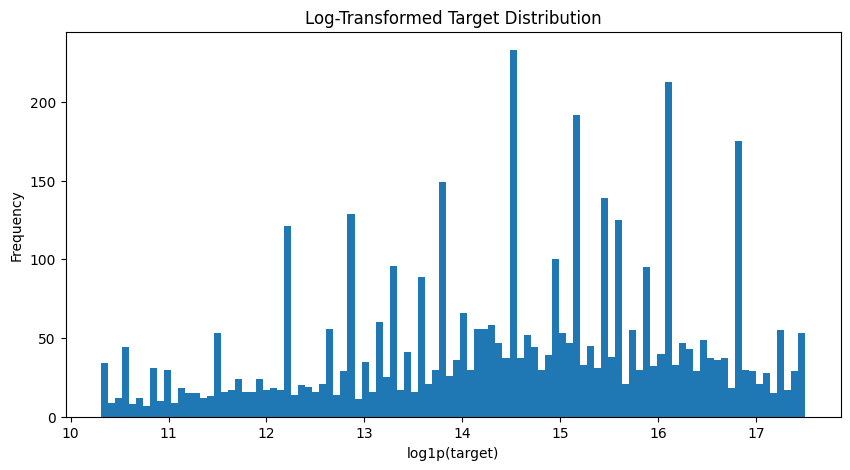

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(y_log, bins=100)

plt.title("Log-Transformed Target Distribution")
plt.xlabel("log1p(target)")
plt.ylabel("Frequency")

plt.show()

In [15]:
ridge_log_model = Ridge(alpha=1.0)

ridge_log_scores = cross_validate(
    ridge_log_model,
    X,
    y_log,
    cv=kf,
    scoring=(
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ),
    return_train_score=True
)

/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/machine_learning_project/.venv_machine_learning_project/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:255: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/michaelfernandolingrios/Documents/neuerfische_course/machine_learning/ma

In [16]:
ridge_log_mae = -ridge_log_scores["test_neg_mean_absolute_error"]
ridge_log_rmse = -ridge_log_scores["test_neg_root_mean_squared_error"]
ridge_log_r2 = ridge_log_scores["test_r2"]

print("Ridge Regression With Log-Target")
print("MAE:", ridge_log_mae.mean())
print("RMSE:", ridge_log_rmse.mean())
print("R²:", ridge_log_r2.mean())

Ridge Regression With Log-Target
MAE: 28459.180287937488
RMSE: 85489.99507195683
R²: -3075242921.6164827


# Log-Target Ridge Regression Findings

Applying a logarithmic transformation significantly reduced the scale of prediction errors.

The transformed target distribution became more stable and less dominated by extreme outliers.

However, despite the improved numerical stability, the model still produced a highly negative R² score.

---

## Interpretation

This suggests that the main limitation is not only target skewness.

The dataset likely contains:

- weak linear relationships
- non-linear interactions
- complex sparse patterns

Ridge Regression can stabilize the model, but it still struggles to explain the target variable effectively.

---

## Modeling Implication

The results suggest that:

- regularization is necessary
- target transformation helps stability
- simple linear models remain insufficient

This motivates testing non-linear models next.

# Decision Tree Regression

The previous experiments showed that linear models struggle on this dataset.

Even after:

- regularization
- target transformation

the models still produced very poor R² scores.

We now test a tree-based model.

---

## Why Decision Trees?

Decision Trees are fundamentally different from linear models.

Instead of fitting a single linear equation, trees split the data into regions based on feature values.

This allows them to capture:

- non-linear relationships
- feature interactions
- threshold effects
- sparse activation patterns

---

## Advantages For This Dataset

Decision Trees are useful here because:

- the dataset is highly sparse
- relationships may not be linear
- feature interactions may matter
- no feature scaling is required

Trees can also naturally ignore many irrelevant features.

---

## Goal Of This Experiment

We want to determine whether a non-linear model can improve performance compared to:

- Dummy baseline
- Linear Regression
- Ridge Regression

We will again use the same cross-validation framework for fair comparison.

In [11]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=10
)

tree_scores = cross_validate(
    tree_model,
    X,
    y,
    cv=kf,
    scoring=(
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ),
    return_train_score=True
)

In [12]:
tree_mae = -tree_scores["test_neg_mean_absolute_error"]
tree_rmse = -tree_scores["test_neg_root_mean_squared_error"]
tree_r2 = tree_scores["test_r2"]

print("Decision Tree Results")
print("MAE:", tree_mae.mean())
print("RMSE:", tree_rmse.mean())
print("R²:", tree_r2.mean())

Decision Tree Results
MAE: 5444813.088668724
RMSE: 8186731.785048452
R²: 0.003219308885089989


# Decision Tree Findings

Decision Tree Regression produced the first positive R² score observed in the project.

Although performance is still limited, this result is important because it suggests that the model is beginning to capture meaningful structure in the dataset.

---

## Interpretation

Compared to linear models, Decision Trees can:

- model non-linear relationships
- capture feature interactions
- split observations into regions
- handle sparse activation patterns more naturally

This likely explains why the tree model performed better.

---

## Important Observation

The R² score remains close to zero, meaning predictive performance is still weak overall.

However, the transition from highly negative R² values to a positive R² score is a major improvement.

This suggests that the dataset contains non-linear structure that linear models could not capture.

---

## Modeling Implication

Future improvements will likely require:

- stronger tree-based ensemble methods
- feature engineering
- more advanced non-linear modeling approaches

# Random Forest Regression

The Decision Tree model produced the first positive R² score in the project.

However, a single tree can still be unstable and sensitive to the training data.

We now test a Random Forest model.

---

## What Is A Random Forest?

A Random Forest is an ensemble model.

Instead of training one decision tree, the model trains many trees and combines their predictions.

Each tree sees:

- a slightly different sample of the data
- a slightly different subset of features

The final prediction is the average prediction across all trees.

---

## Why Random Forests Often Perform Better

Single trees can overfit easily.

Random Forests reduce this problem by averaging many trees together.

This often improves:

- stability
- generalization
- robustness
- predictive performance

---

## Why This Model Fits Our Dataset

Random Forests are useful for this dataset because they can:

- capture non-linear relationships
- handle sparse features
- model feature interactions
- ignore many irrelevant variables automatically

---

## Goal Of This Experiment

We want to determine whether combining many trees improves performance compared to:

- Linear Regression
- Ridge Regression
- a single Decision Tree

In [13]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest_scores = cross_validate(
    forest_model,
    X,
    y,
    cv=kf,
    scoring=(
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error",
        "r2"
    ),
    return_train_score=True
)

In [21]:
forest_mae = -forest_scores["test_neg_mean_absolute_error"]
forest_rmse = -forest_scores["test_neg_root_mean_squared_error"]
forest_r2 = forest_scores["test_r2"]

print("Random Forest Results")
print("MAE:", forest_mae.mean())
print("RMSE:", forest_rmse.mean())
print("R²:", forest_r2.mean())

Random Forest Results
MAE: 5130281.796040111
RMSE: 7302710.862647332
R²: 0.20820847651407579


# Random Forest Findings

Random Forest Regression produced the strongest performance observed so far.

The model achieved a substantially higher R² score compared to all previous approaches.

---

## Interpretation

The improvement suggests that the dataset contains:

- non-linear relationships
- feature interactions
- complex sparse patterns

Random Forests are able to capture these relationships more effectively than linear models.

---

## Why Performance Improved

Unlike a single Decision Tree, Random Forest combines many trees together.

This averaging process:

- reduces overfitting
- improves stability
- increases robustness
- improves generalization

---

## Important Observation

The model still leaves a large portion of variance unexplained.

However, compared to previous models, Random Forest demonstrates that meaningful predictive structure exists in the dataset.

---

## Modeling Implication

Tree-based ensemble methods appear substantially more suitable for this dataset than simple linear models.

Future improvements may come from:

- feature engineering
- hyperparameter tuning
- boosting methods
- advanced ensemble approaches